# 1. Project Overview

# Chicago Food Inspection Analysis

## Business Question
Can we identify patterns in food inspection results and predict which establishments are at higher risk of failing an inspection?

## Objectives
- Understand dataset structure
- Analyze data quality
- Explore inspection patterns
- Analyze textual violation reports
- Prepare data for machine learning

# 2. Imports and Data Collection

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter



In [167]:
#
url = "https://data.cityofchicago.org/resource/4ijn-s7e5.csv?$limit=50000"

df = pd.read_csv(url)

print(df.shape)
df.head()

(50000, 17)


,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2638740,THE BAGEL INC,THE BAGEL,29989.0,Restaurant,Risk 1 (High),3107 N BROADWAY,CHICAGO,IL,60657.0,2026-06-18T00:00:00.000,Complaint Re-Inspection,Pass,47. FOOD & NON-FOOD CONTACT SURFACES CLEANABLE...,41.938000,-87.644185,"\n, \n(41.93799979314034, -87.64418473186258)"
1,2638653,POK POK THAI,POK POK THAI,3086752.0,Restaurant,Risk 1 (High),4156 N KEDZIE AVE,CHICAGO,IL,60618.0,2026-06-17T00:00:00.000,License Re-Inspection,Pass,47. FOOD & NON-FOOD CONTACT SURFACES CLEANABLE...,41.957447,-87.708272,"\n, \n(41.95744728247397, -87.70827183208556)"
2,2638726,Con Azucar Cafe Chicago,Con Azucar Cafe Chicago,3090182.0,NaN,Risk 2 (Medium),801 S FINANCIAL PL,CHICAGO,IL,60605.0,2026-06-17T00:00:00.000,License,Not Ready,NaN,41.872102,-87.632797,"\n, \n(41.87210229663722, -87.6327971339645)"
3,2638672,"DE BAK FOREVER, INC.",KIMCHI POP LINCOLN SQUARE,3087100.0,Restaurant,Risk 1 (High),4757 N WESTERN AVE,CHICAGO,IL,60625.0,2026-06-17T00:00:00.000,License,Pass,49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Com...,41.968412,-87.688755,"\n, \n(41.96841242589265, -87.68875511181906)"
4,2638642,HELEN LUCY CHILD CARE INC.,HELEN LUCY CHILD CARE,2215992.0,Children's Services Facility,Risk 1 (High),5801 N NORTHWEST HWY,CHICAGO,IL,60631.0,2026-06-17T00:00:00.000,License,Pass,NaN,41.987033,-87.789381,"\n, \n(41.98703322680841, -87.78938143174634)"


# 3. Initial Data Exploration

### Dataset Overview

In [168]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inspection_id    50000 non-null  int64  
 1   dba_name         50000 non-null  str    
 2   aka_name         49955 non-null  str    
 3   license_         49998 non-null  float64
 4   facility_type    49705 non-null  str    
 5   risk             49986 non-null  str    
 6   address          50000 non-null  str    
 7   city             49950 non-null  str    
 8   state            49980 non-null  str    
 9   zip              49998 non-null  float64
 10  inspection_date  50000 non-null  str    
 11  inspection_type  50000 non-null  str    
 12  results          50000 non-null  str    
 13  violations       33865 non-null  str    
 14  latitude         49817 non-null  float64
 15  longitude        49817 non-null  float64
 16  location         49817 non-null  str    
dtypes: float64(4), int64(1)

### Columns

In [169]:
df.columns

Index(['inspection_id', 'dba_name', 'aka_name', 'license_', 'facility_type',
       'risk', 'address', 'city', 'state', 'zip', 'inspection_date',
       'inspection_type', 'results', 'violations', 'latitude', 'longitude',
       'location'],
      dtype='str')

### Datatypes

In [170]:
df.dtypes

inspection_id        int64
dba_name               str
aka_name               str
license_           float64
facility_type          str
risk                   str
address                str
city                   str
state                  str
zip                float64
inspection_date        str
inspection_type        str
results                str
violations             str
latitude           float64
longitude          float64
location               str
dtype: object

### Descriptive Statistics

In [171]:
df.describe(include='all')

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
count,5.000000e+04,50000,49955,4.999800e+04,49705,49986,50000,49950,49980,49998.000000,50000,50000,50000,33865,49817.000000,49817.000000,49817
unique,NaN,13419,12938,NaN,191,4,19697,35,5,NaN,658,15,7,33538,NaN,NaN,19417
top,NaN,SUBWAY,SUBWAY,NaN,Restaurant,Risk 1 (High),11601 W TOUHY AVE,CHICAGO,IL,NaN,2024-10-08T00:00:00.000,Canvass,Pass,58. ALLERGEN TRAINING AS REQUIRED - Comments: ...,NaN,NaN,"\n, \n(42.00875076599798, -87.90687413400109)"
freq,NaN,535,649,NaN,35637,40164,463,49755,49969,NaN,125,25372,26536,13,NaN,NaN,467
mean,2.610982e+06,NaN,NaN,2.250772e+06,NaN,NaN,NaN,NaN,NaN,60629.397756,NaN,NaN,NaN,NaN,41.879422,-87.675290,NaN
std,1.583136e+04,NaN,NaN,9.326434e+05,NaN,NaN,NaN,NaN,NaN,290.394960,NaN,NaN,NaN,NaN,0.079349,0.058995,NaN
min,2.583701e+06,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,46322.000000,NaN,NaN,NaN,NaN,41.644670,-87.906874,NaN
25%,2.596354e+06,NaN,NaN,2.066649e+06,NaN,NaN,NaN,NaN,NaN,60614.000000,NaN,NaN,NaN,NaN,41.835224,-87.706135,NaN
50%,2.611918e+06,NaN,NaN,2.578643e+06,NaN,NaN,NaN,NaN,NaN,60625.000000,NaN,NaN,NaN,NaN,41.891193,-87.664597,NaN
75%,2.624511e+06,NaN,NaN,2.895973e+06,NaN,NaN,NaN,NaN,NaN,60643.000000,NaN,NaN,NaN,NaN,41.937067,-87.634269,NaN


The dataset contains numerical, categorical, and textual variables.
The most important target-related variable is `results`, while `violations` contains unstructured text.

In [212]:
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")
df["inspection_date"].dtype
df["inspection_date"].isna().sum()

np.int64(0)

In [213]:
df["year"] = df["inspection_date"].dt.year
df["month"] = df["inspection_date"].dt.month
df["weekday"] = df["inspection_date"].dt.day_name()

<Axes: xlabel='year'>

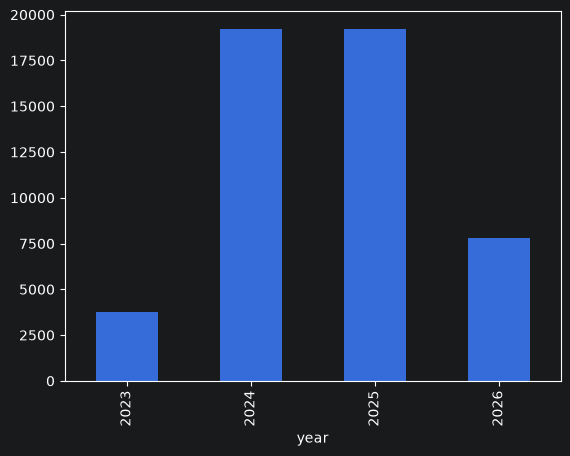

# 4. Data Quality Assessment

### Missing values

In [172]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

violations         16135
facility_type        295
longitude            183
location             183
latitude             183
city                  50
aka_name              45
state                 20
risk                  14
license_               2
zip                    2
inspection_id          0
dba_name               0
address                0
results                0
inspection_date        0
inspection_type        0
dtype: int64

### Missing Values Distribution

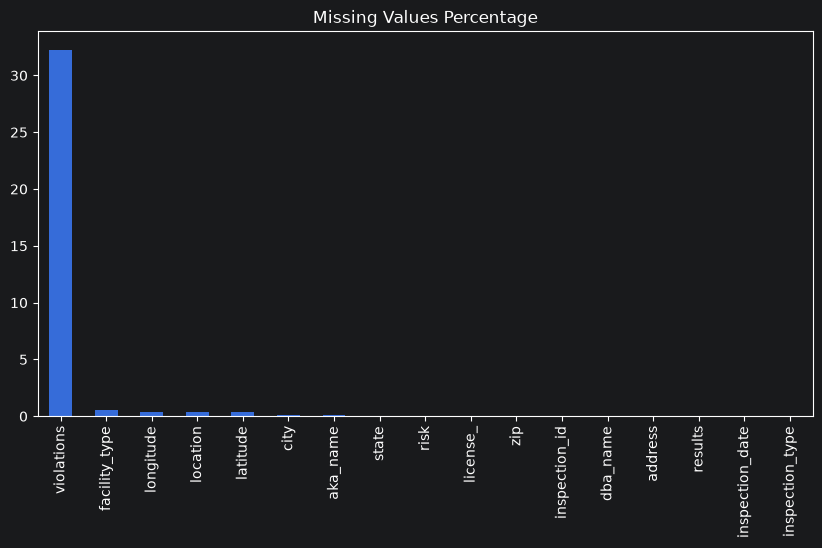

In [173]:
missing_percent = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percent.plot(kind="bar", figsize=(10,5))
plt.title("Missing Values Percentage")
plt.show()

### Missing Values in Violations

In [174]:
df[df["violations"].isna()]["results"].value_counts()

results
Pass                    7583
Out of Business         3498
No Entry                3480
Not Ready               1185
Fail                     216
Pass w/ Conditions       162
Business Not Located      11
Name: count, dtype: int64

In [175]:
pass_total = (df["results"] == "Pass").sum()

pass_missing = df[
    (df["results"] == "Pass") &
    (df["violations"].isna())
].shape[0]

violations_pass = pass_missing / pass_total * 100
print(round(violations_pass, 2), "%")

28.58 %


### Cleaning Missing Values

In [176]:
df["violations_clean"] = df["violations"].fillna(
    "NO_VIOLATION_RECORDED"
)

df["facility_type"] = df["facility_type"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")

### Missing Values by Result

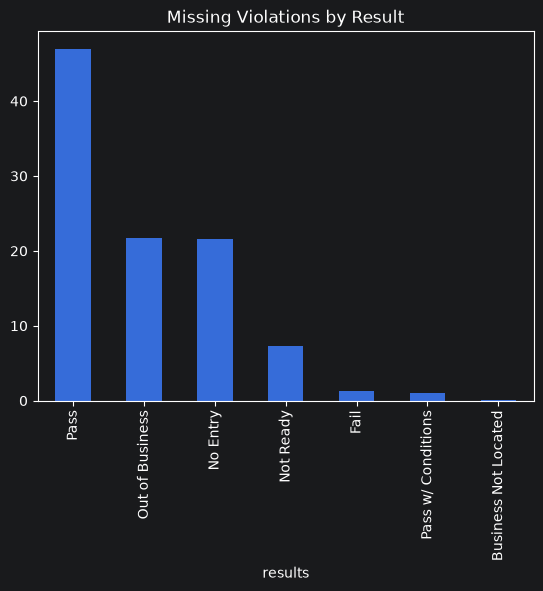

In [177]:
missing_by_result = (
    df[df["violations"].isna()]
    ["results"]
    .value_counts(normalize=True) * 100
)

missing_by_result.plot(kind="bar")
plt.title("Missing Violations by Result")
plt.show()

Missing values in `violations` are not random.
They occur mainly in inspections labeled Pass, No Entry, or Out of Business.
Therefore, missing values contain semantic information.

## 4.2 Duplicates

In [178]:
df.duplicated().sum()

np.int64(0)

No exact duplicate rows were found.

## 4.3 Outlier Analysis

### Violations Length

In [179]:
df["violations_length"] = (
    df["violations"]
    .fillna("")
    .str.len()
)

In [180]:
df["violations_length"].describe()

count    50000.000000
mean       775.959980
std        978.599578
min          0.000000
25%          0.000000
50%        445.000000
75%       1157.000000
max      12706.000000
Name: violations_length, dtype: float64

### Boxplot

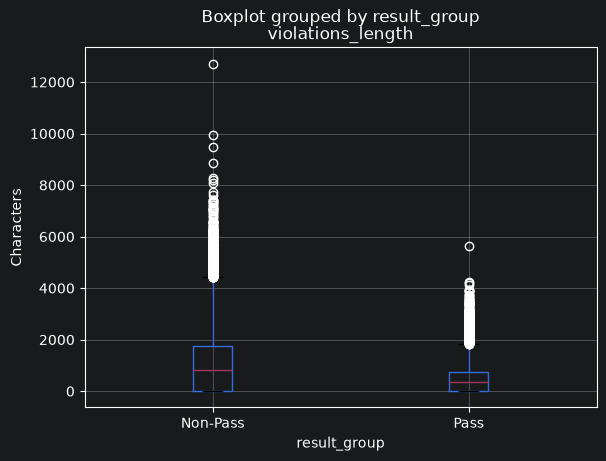

In [181]:
df["result_group"] = df["results"].apply(
    lambda x: "Pass" if x == "Pass" else "Non-Pass"
)

df.boxplot(
    column="violations_length",
    by="result_group"
)
plt.ylabel("Characters")
plt.show()

Violation lengths are highly right-skewed.
Many inspections contain no violations, while a small number contain very long reports.

## 5. Exploratory Data Analysis

## 5.1 Inspection Results

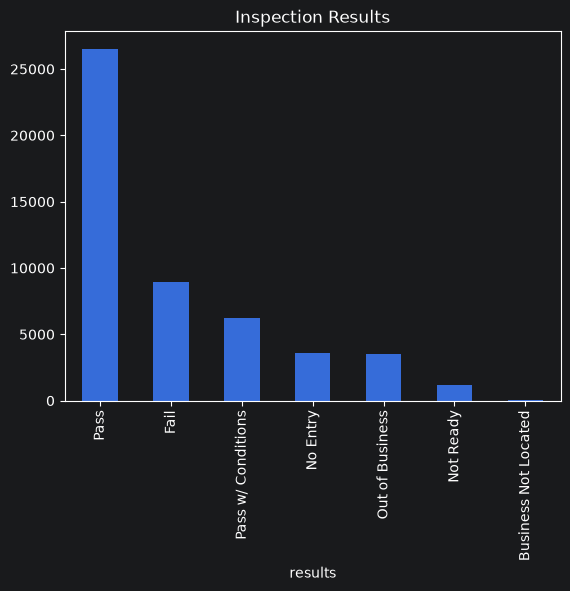

In [182]:
df["results"].value_counts().plot(kind="bar")
plt.title("Inspection Results")
plt.show()

## 5.2 Risk Categories

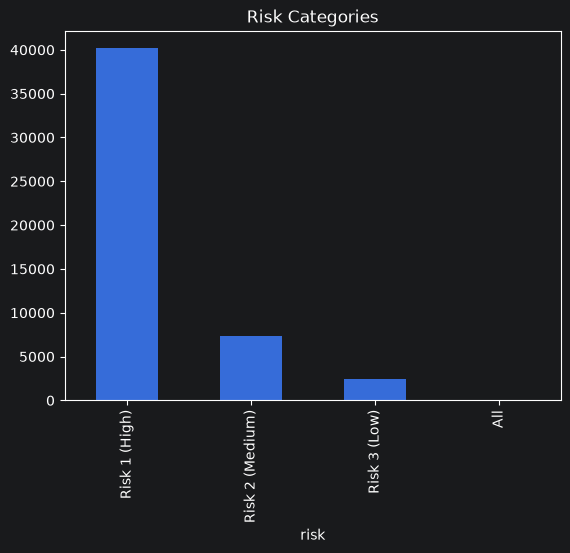

In [183]:
df["risk"].value_counts().plot(kind="bar")
plt.title("Risk Categories")
plt.show()

## 5.3 Facility Types

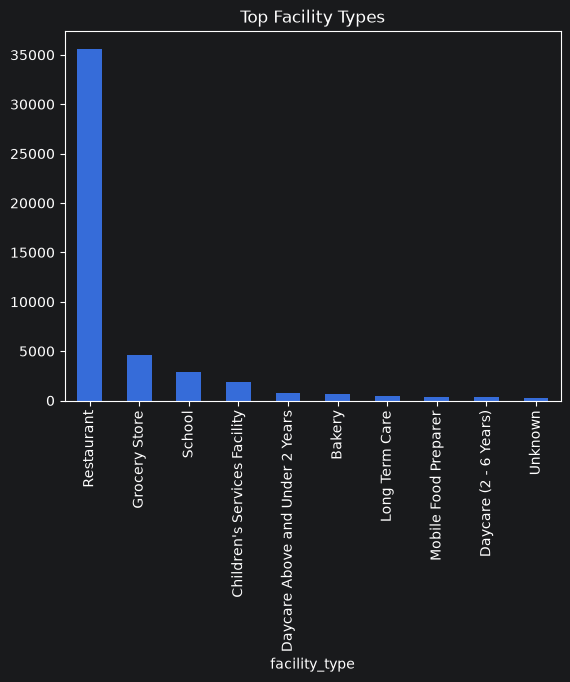

In [184]:
df["facility_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top Facility Types")
plt.show()

In [185]:
df["facility_type"] = df["facility_type"].fillna("Unknown")

df["facility_type"].value_counts().head(20)

facility_type
Restaurant                         35637
Grocery Store                       4660
School                              2897
Children's Services Facility        1841
Daycare Above and Under 2 Years      729
Bakery                               708
Long Term Care                       479
Mobile Food Preparer                 351
Daycare (2 - 6 Years)                317
Unknown                              295
Catering                             294
Liquor                               212
Hospital                             172
Shared Kitchen User (Long Term)      164
Golden Diner                         145
Shared Kitchen                       109
Special Event                         65
TAVERN                                49
CHARTER SCHOOL                        38
Daycare Combo 1586                    35
Name: count, dtype: int64

## Month

In [ ]:
df["month"].value_counts().sort_index().plot(kind="bar")

## Year

<Axes: xlabel='year'>

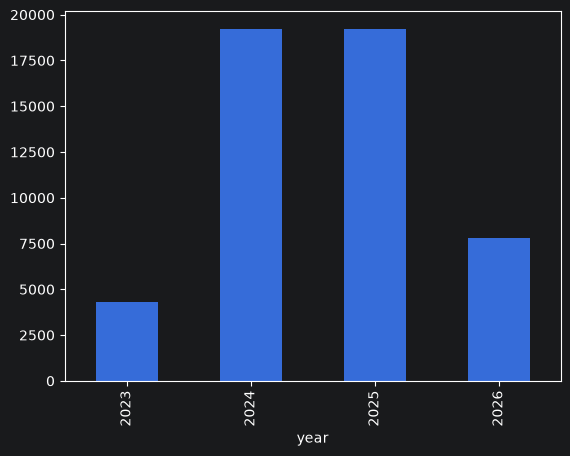

In [219]:

df["year"].value_counts().sort_index().plot(kind="bar")

## Inspection / Weekdays

In [ ]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["weekday"] = pd.Categorical(df["weekday"], categories=order, ordered=True)

df["weekday"].value_counts().sort_index().plot(kind="bar")

## Inspection Type

In [ ]:
## Licence Type
df["inspection_type"].value_counts()
df["inspection_type"].value_counts().plot(kind="bar")

## Inspection Type vs Result

In [220]:
pd.crosstab(df["inspection_type"], df["results"])

results,Business Not Located,Fail,No Entry,Not Ready,Out of Business,Pass,Pass w/ Conditions
inspection_type,,,,,,,
ASSESSMENT,0,1,0,0,0,0,0
Canvass,6,5014,102,6,3448,12939,3857
Canvass Re-Inspection,0,621,44,1,7,5043,364
Complaint,0,1478,349,1,13,1856,845
Complaint Re-Inspection,0,242,19,0,5,1415,121
Consultation,0,0,0,0,0,2,0
License,1,1307,108,1157,3,3426,691
License Re-Inspection,0,101,4,2,2,1113,170
Non-Inspection,4,2,2960,18,18,4,3


<Axes: xlabel='inspection_type'>

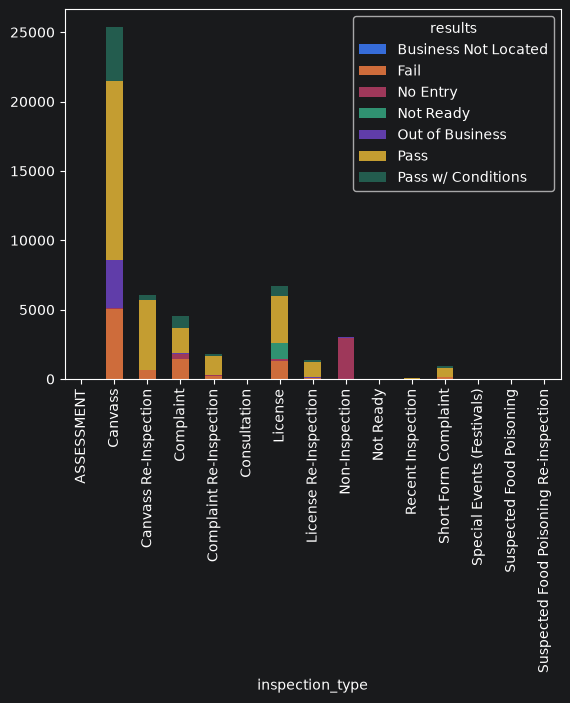

In [221]:
pd.crosstab(df["inspection_type"], df["results"]).plot(kind="bar", stacked=True)

## Fails pro Ort

In [226]:
fails = df[df["results"] == "Fail"]

fails_by_zip = fails["zip"].value_counts()
fails_by_zip.head(20)

zip
60616.0    395
60622.0    383
60614.0    344
60611.0    321
60608.0    315
60625.0    312
60639.0    309
60654.0    303
60647.0    292
60657.0    265
60617.0    263
60607.0    261
60620.0    240
60632.0    211
60612.0    195
60651.0    194
60619.0    186
60613.0    185
60618.0    180
60660.0    176
Name: count, dtype: int64

In [227]:
zip_stats = df.groupby("zip").agg(
    total=("inspection_id", "count"),
    fails=("results", lambda x: (x == "Fail").sum())
)

zip_stats["fail_rate"] = zip_stats["fails"] / zip_stats["total"]

zip_stats.sort_values("fail_rate", ascending=False).head(20)

,total,fails,fail_rate
zip,,,
60475.0,1,1,1.000000
60827.0,34,11,0.323529
60620.0,883,240,0.271801
60636.0,545,145,0.266055
60617.0,1015,263,0.259113
60660.0,685,176,0.256934
60624.0,469,112,0.238806
60616.0,1664,395,0.237380
60651.0,825,194,0.235152


<Axes: xlabel='zip'>

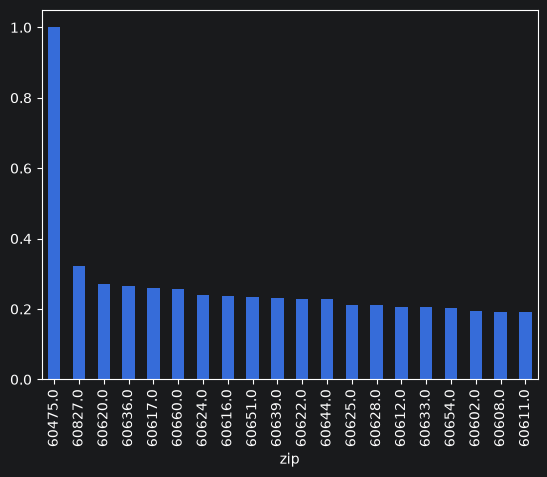

In [228]:
zip_stats.sort_values("fail_rate", ascending=False)["fail_rate"].head(20).plot(
    kind="bar"
)

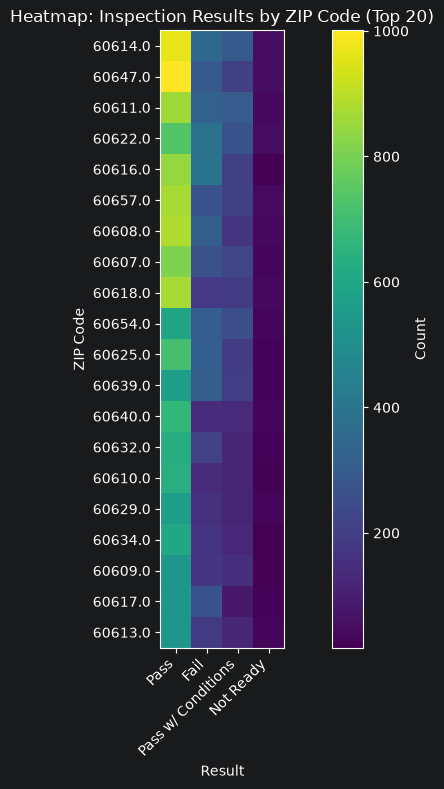

In [229]:
# Crosstab: ZIP vs Inspection Result
ct = pd.crosstab(df["zip"], df["results"])

# Optional: nur Top 20 ZIPs (nach Anzahl Inspections)
top_zips = df["zip"].value_counts().head(20).index
ct = ct.loc[top_zips]

# Spalten sortieren (falls vorhanden)
preferred_order = ["Pass", "Fail", "Pass w/ Conditions", "Not Ready"]
ct = ct[[c for c in preferred_order if c in ct.columns]]

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(ct.values)

plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.yticks(range(len(ct.index)), ct.index)

plt.title("Heatmap: Inspection Results by ZIP Code (Top 20)")
plt.xlabel("Result")
plt.ylabel("ZIP Code")

plt.colorbar(label="Count")

plt.tight_layout()
plt.show()

# 6. Text Analysis of Violations

In [186]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

In [187]:
text = " ".join(
    df["violations"]
    .fillna("")
    .astype(str)
)

words = re.findall(r"\b[a-z]+\b", text.lower())
Counter(words).most_common(30)

[('and', 206880),
 ('to', 155870),
 ('food', 152712),
 ('comments', 152176),
 ('the', 146113),
 ('in', 143656),
 ('instructed', 109292),
 ('observed', 106125),
 ('of', 99592),
 ('clean', 81309),
 ('on', 74480),
 ('maintain', 65634),
 ('at', 63061),
 ('all', 60259),
 ('must', 54412),
 ('properly', 50734),
 ('area', 50181),
 ('prep', 43539),
 ('a', 39640),
 ('installed', 39612),
 ('facilities', 38034),
 ('used', 36891),
 ('for', 36033),
 ('no', 35888),
 ('maintained', 34792),
 ('surfaces', 34452),
 ('sink', 34356),
 ('with', 34197),
 ('priority', 33825),
 ('provide', 33421)]

In [188]:
stop_words = set(ENGLISH_STOP_WORDS)
words = [w for w in words if w not in stop_words]

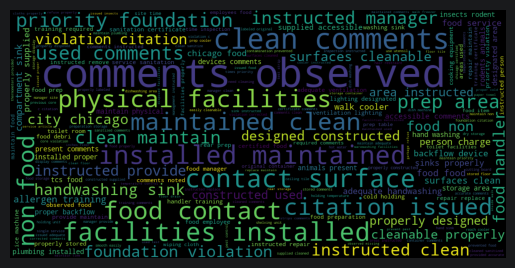

In [189]:
wordcloud = WordCloud(
    width=1000,
    height=500
).generate(" ".join(words))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [190]:
codes = []

for row in df["violations"].dropna():
    codes.extend(re.findall(r"(\d+)\.", row))

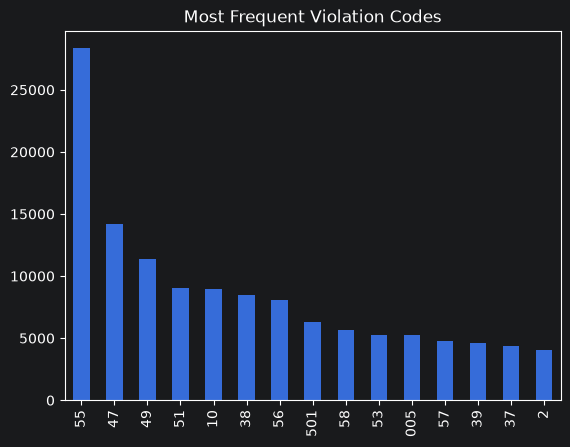

In [191]:
pd.Series(codes).value_counts().head(15).plot(kind="bar")
plt.title("Most Frequent Violation Codes")
plt.show()

## Key Findings

- Missing values in violations are informative rather than random
- Inspection results are imbalanced
- Violation reports are highly skewed
- Several violation categories occur frequently
- Text features may help prediction models

In [192]:
df["city"].value_counts()
df["city"] = df["city"].fillna("Unknown")
df["city"].value_counts()

city
CHICAGO            49755
Chicago               98
Unknown               50
chicago               24
EVANSTON               9
CCHICAGO               9
CHICAGOO               7
OAK PARK               4
BERWYN                 4
312CHICAGO             4
MERRIVILLE             3
CHICAGO.               3
RIPON                  2
SKOKIE                 2
CH                     2
CHICAGOCHICAGO         2
CHicago                2
NAPERVILLE             2
BOLINGBROOK            1
ELMHURST               1
CAROL STREAM           1
AURORA                 1
TORRANCE               1
LOS ANGELES            1
BALDWIN PARK           1
MOUNT PROSPECT         1
GRAYSLAKE              1
BROOKFIELD             1
HAMMOND                1
MERRILLVILLE           1
BURBANK                1
EVERGREEN              1
MATTESON               1
HIGHLAND PARK          1
WESTERN SPRINGS        1
PLAINFIELD             1
Name: count, dtype: int64

In [193]:
df["risk"].value_counts(dropna=False)

risk
Risk 1 (High)      40164
Risk 2 (Medium)     7290
Risk 3 (Low)        2482
All                   50
NaN                   14
Name: count, dtype: int64

<Axes: >

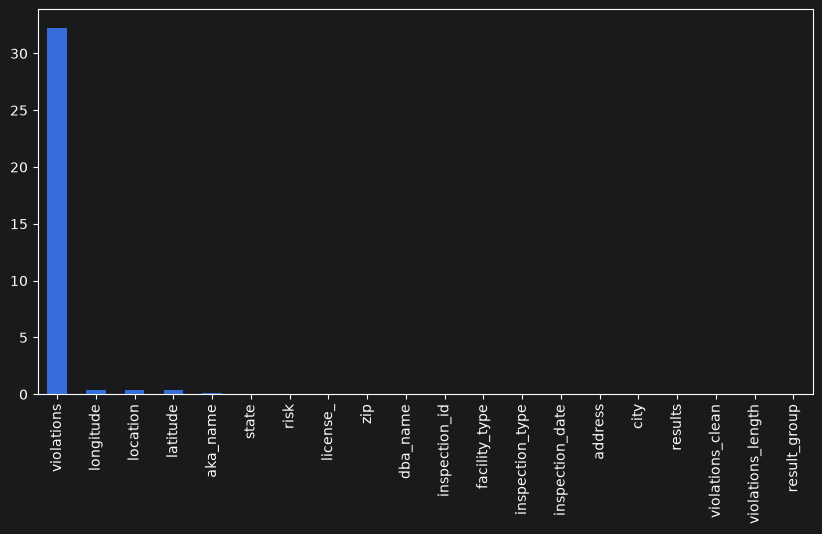

In [194]:
missing_percent = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percent.plot(kind="bar", figsize=(10,5))

<Axes: >

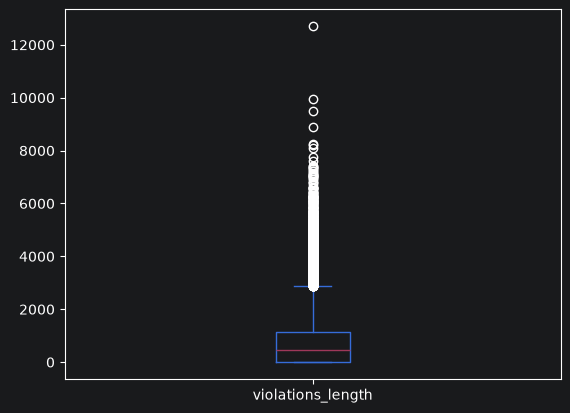

In [195]:
df['violations_length'] = (
    df['violations']
    .fillna("")
    .str.len()
)

df["violations_length"].plot(kind="box")

In [196]:
df["violations_length"].describe()

count    50000.000000
mean       775.959980
std        978.599578
min          0.000000
25%          0.000000
50%        445.000000
75%       1157.000000
max      12706.000000
Name: violations_length, dtype: float64

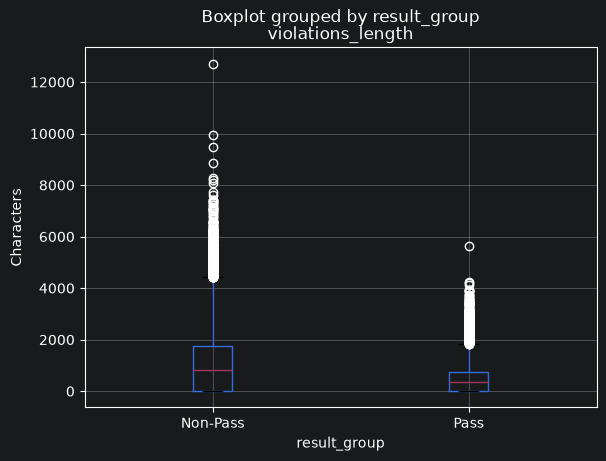

In [197]:
df["result_group"] = df["results"].apply(
    lambda x: "Pass" if x == "Pass" else "Non-Pass"
)

df.boxplot(column="violations_length", by="result_group")
plt.ylabel("Characters")
plt.show()

sehr viele Werte nahe 0, viele Outliers, da viele Pass Inspektionen keine Violations enthalten

A substantial portion of inspections have no recorded violations, which creates a large concentration of values near zero.

------------------

Duplicates

In [198]:
print(df.duplicated().sum())

0


In [199]:
from collections import Counter
import re

text = " ".join(
    df['violations']
    .fillna("")
    .astype(str)
)

words = re.findall(r'\b[a-z]+\b', text.lower())

Counter(words).most_common(30)

[('and', 206880),
 ('to', 155870),
 ('food', 152712),
 ('comments', 152176),
 ('the', 146113),
 ('in', 143656),
 ('instructed', 109292),
 ('observed', 106125),
 ('of', 99592),
 ('clean', 81309),
 ('on', 74480),
 ('maintain', 65634),
 ('at', 63061),
 ('all', 60259),
 ('must', 54412),
 ('properly', 50734),
 ('area', 50181),
 ('prep', 43539),
 ('a', 39640),
 ('installed', 39612),
 ('facilities', 38034),
 ('used', 36891),
 ('for', 36033),
 ('no', 35888),
 ('maintained', 34792),
 ('surfaces', 34452),
 ('sink', 34356),
 ('with', 34197),
 ('priority', 33825),
 ('provide', 33421)]

In [200]:
import sys
print(sys.executable)

import pkgutil
print(any("wordcloud" in m.name for m in pkgutil.iter_modules()))

D:\Datensicherung BHT\_DataScience\usecase\.venv\Scripts\python.exe
True


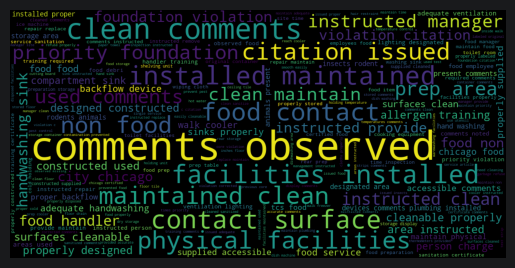

In [201]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


stop_words = set(ENGLISH_STOP_WORDS)

words = [w for w in words if w not in stop_words]

from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=500
).generate(" ".join(words))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

<Axes: >

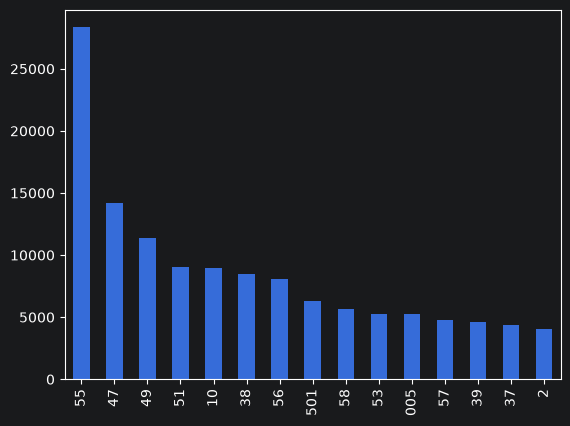

In [202]:
import re

codes = []

for row in df["violations"].dropna():
    found = re.findall(r'(\d+)\.', row)
    codes.extend(found)

pd.Series(codes).value_counts().head(15).plot(kind="bar")

<Axes: xlabel='results'>

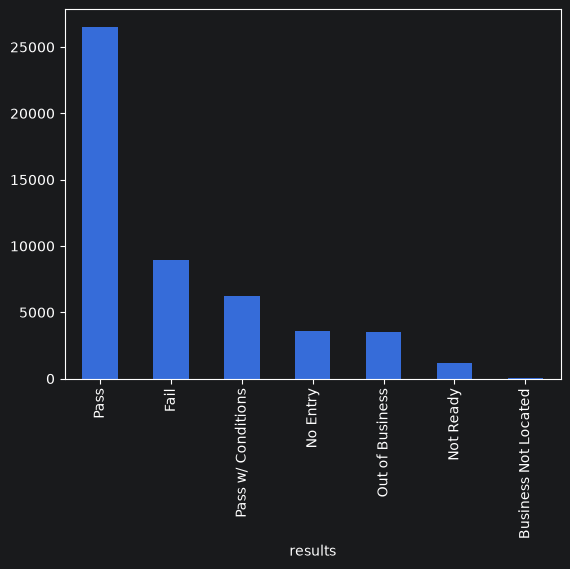

In [203]:
df["results"].value_counts().plot(kind="bar")

<Axes: xlabel='risk'>

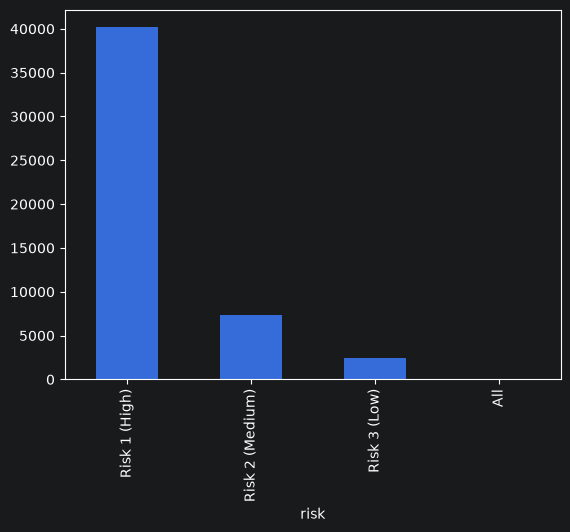

In [204]:
df["risk"].value_counts().plot(kind="bar")

<Axes: xlabel='facility_type'>

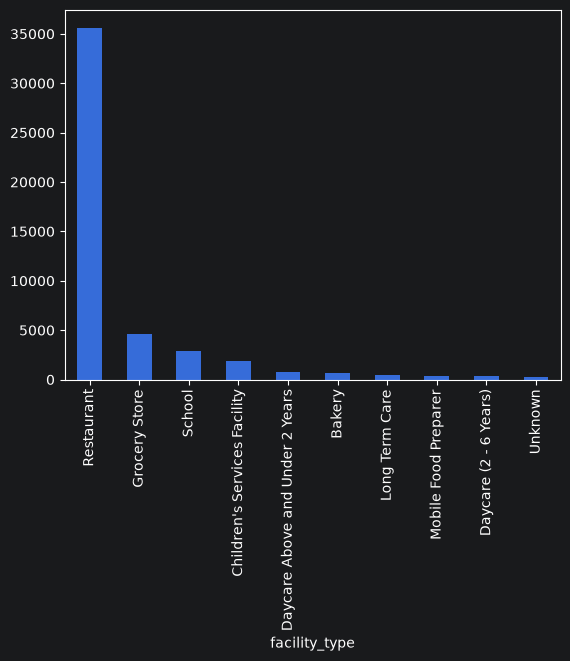

In [205]:
df["facility_type"].value_counts().head(10).plot(kind="bar")